In [1]:
import gymnasium as gym

Instantiate the first environment.

In [2]:
env = gym.make('Pendulum-v1')

## Print OBSERVATION and ACTION spaces
print('Observation space:', env.observation_space)
print('Observation space shape:', env.observation_space.shape) # Tells the number of input nodes for the NN

print('Action space:', env.action_space)
print('Action space shape:', env.action_space.shape) # Tells the number of output nodes for the NN

Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Observation space shape: (3,)
Action space: Box(-2.0, 2.0, (1,), float32)
Action space shape: (1,)


In [3]:
env = gym.make('Pendulum-v1')

# INITIALIZE THE ENVIRONMENT
state, info = env.reset() # reset() returns the initial state and a dictionary of extra info
print("Initial state:", state)

step_count = 0

# RUN THE LOOP
while True:
    step_count += 1
    
    # Sample a random continuous action
    random_action = env.action_space.sample()
    
    # 3. THE GYMNASIUM STEP
    next_state, reward, terminated, truncated, info = env.step(random_action)
    
    print(f'\n--- Step {step_count} ---')
    print('Action taken:', random_action.shape)
    print('Next State:', next_state.shape)
    print('Reward received:', reward.shape)
    
    # Episode ends if it naturally finishes (terminated) OR if it hits a time limit (truncated)
    done = terminated or truncated
    print('Is episode over?:', done)
    
    # PREPARE FOR THE NEXT LOOP
    # The next_state now becomes our current state
    state = next_state 
    
    if done:
        print(f"\nEpisode finished after {step_count} steps!")
        break # Exit the loop so it doesn't run forever
        
env.close()

Initial state: [ 0.7449678  -0.66710037  0.8988438 ]

--- Step 1 ---
Action taken: (1,)
Next State: (3,)
Reward received: ()
Is episode over?: False

--- Step 2 ---
Action taken: (1,)
Next State: (3,)
Reward received: ()
Is episode over?: False

--- Step 3 ---
Action taken: (1,)
Next State: (3,)
Reward received: ()
Is episode over?: False

--- Step 4 ---
Action taken: (1,)
Next State: (3,)
Reward received: ()
Is episode over?: False

--- Step 5 ---
Action taken: (1,)
Next State: (3,)
Reward received: ()
Is episode over?: False

--- Step 6 ---
Action taken: (1,)
Next State: (3,)
Reward received: ()
Is episode over?: False

--- Step 7 ---
Action taken: (1,)
Next State: (3,)
Reward received: ()
Is episode over?: False

--- Step 8 ---
Action taken: (1,)
Next State: (3,)
Reward received: ()
Is episode over?: False

--- Step 9 ---
Action taken: (1,)
Next State: (3,)
Reward received: ()
Is episode over?: False

--- Step 10 ---
Action taken: (1,)
Next State: (3,)
Reward received: ()
Is episode

## SAC LEARNING ALGORITHM:

Training SAC: 100%|██████████| 20000/20000 [02:39<00:00, 125.36it/s]


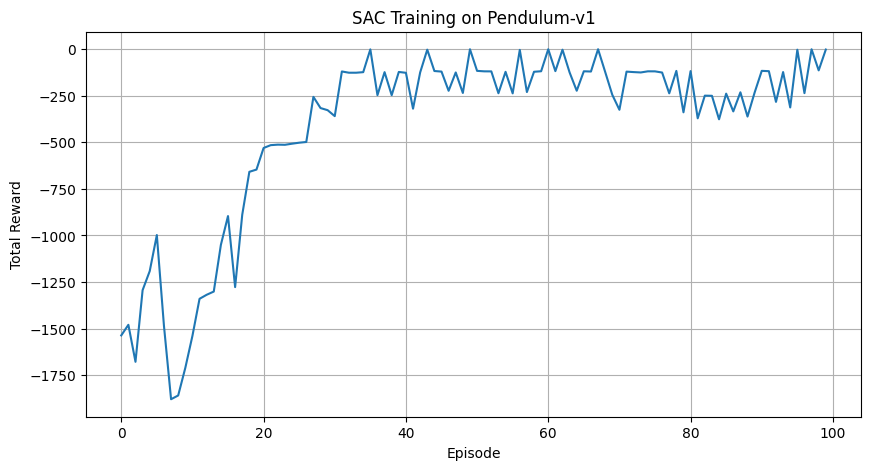

In [4]:
import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

# Import your custom modules (assuming they are in the 'src' folder)
from src.buffer import ReplayBuffer
from src.networks import Actor, Critic
from src.sac import SAC

# 1. SETUP
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
env = gym.make('Pendulum-v1')

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

replay_buffer = ReplayBuffer(state_dim, action_dim)
agent = SAC(state_dim, action_dim, max_action, device)

# Hyperparameters
max_timesteps = 20000       # Total steps to train (Pendulum learns very fast)
start_timesteps = 1000      # Steps of purely random actions to fill buffer
batch_size = 256
episode_rewards = []        # To store data for our plot
current_episode_reward = 0

state, _ = env.reset()

# 2. MAIN LOOP
for t in tqdm(range(max_timesteps), desc="Training SAC"):
    
    # a) Select Action (Randomly for warm-up, then using Policy)
    if t < start_timesteps:
        action = env.action_space.sample()
    else:
        action = agent.select_action(state)
        
    # b) Take Step in Environment
    next_state, reward, terminated, truncated, _ = env.step(action)
    current_episode_reward += reward
    
    # Mathematical note: We only tell the buffer done=True if the episode 
    # ended naturally (terminated), NOT if it just hit the time limit (truncated).
    done_bool = float(terminated) 
    
    # c) Store in Memory
    replay_buffer.add(state, action, reward, next_state, done_bool)
    
    state = next_state
    
    # d) Train Agent (Only after warm-up is over)
    if t >= start_timesteps:
        agent.train(replay_buffer, batch_size)
        
    # e) Handle Episode End
    if terminated or truncated:
        episode_rewards.append(current_episode_reward)
        state, _ = env.reset()
        current_episode_reward = 0

env.close()

# 3. PLOT RESULTS
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.title("SAC Training on Pendulum-v1")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

In [5]:
print(f'Minimum: {min(episode_rewards)}')
print(f'Maximum: {max(episode_rewards)}')
print(f'Average reward over last 10 episodes: {np.mean(episode_rewards[-10:])}')
print(f'Number of episodes: {len(episode_rewards)}')


Minimum: -1879.3381278894205
Maximum: -0.48966738172147906
Average reward over last 10 episodes: -131.05049596258831
Number of episodes: 100


## REDQ LEARNING ALGORITHM:

Training REDQ: 100%|██████████| 10000/10000 [47:16<00:00,  3.53it/s] 


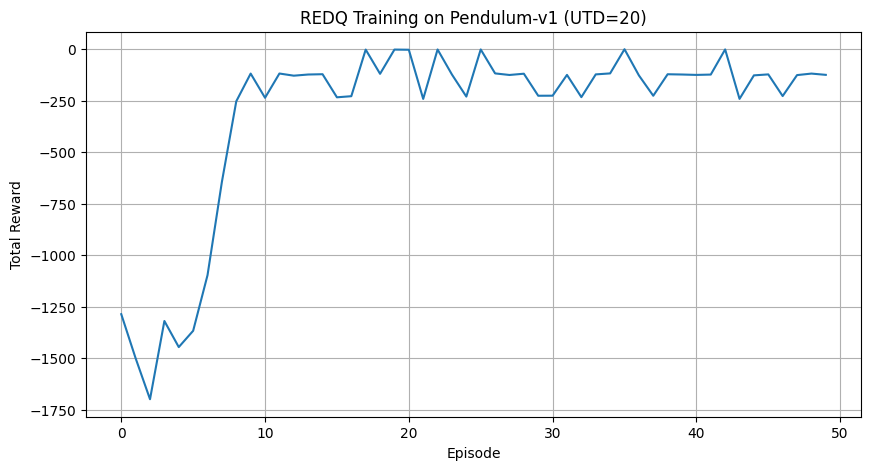

In [3]:
import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

# Import your custom modules 
from src.buffer import ReplayBuffer
# --- CHANGED: Import REDQ instead of SAC ---
from src.redq import REDQ 

# 1. SETUP
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
env = gym.make('Pendulum-v1')

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

replay_buffer = ReplayBuffer(state_dim, action_dim)

# --- CHANGED: Initialize the REDQ Agent ---
agent = REDQ(state_dim, action_dim, max_action, device)

# Hyperparameters
# REDQ is much more sample efficient, so 10,000 steps is usually more than enough!
max_timesteps = 10000       
start_timesteps = 1000      
batch_size = 256
utd_ratio = 20              # <--- NEW: Explicitly define the UTD ratio

episode_rewards = []        
current_episode_reward = 0

state, _ = env.reset()

# 2. MAIN LOOP
# --- CHANGED: tqdm description ---
for t in tqdm(range(max_timesteps), desc="Training REDQ"):
    
    # a) Select Action (Randomly for warm-up, then using Policy)
    if t < start_timesteps:
        action = env.action_space.sample()
    else:
        action = agent.select_action(state)
        
    # b) Take Step in Environment
    next_state, reward, terminated, truncated, _ = env.step(action)
    current_episode_reward += reward
    
    # Mathematical note: We only tell the buffer done=True if the episode 
    # ended naturally (terminated), NOT if it just hit the time limit (truncated).
    done_bool = float(terminated) 
    
    # c) Store in Memory
    replay_buffer.add(state, action, reward, next_state, done_bool)
    
    state = next_state
    
    # d) Train Agent (Only after warm-up is over)
    if t >= start_timesteps:
        # --- CHANGED: Pass the UTD ratio into the train function ---
        agent.train(replay_buffer, batch_size, utd_ratio=utd_ratio)
        
    # e) Handle Episode End
    if terminated or truncated:
        episode_rewards.append(current_episode_reward)
        state, _ = env.reset()
        current_episode_reward = 0

env.close()

# 3. PLOT RESULTS
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
# --- CHANGED: Plot title ---
plt.title(f"REDQ Training on Pendulum-v1 (UTD={utd_ratio})")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

In [4]:
print(f'Minimum: {min(episode_rewards)}')
print(f'Maximum: {max(episode_rewards)}')
print(f'Average reward over last 10 episodes: {np.mean(episode_rewards[-10:])}')
print(f'Number of episodes: {len(episode_rewards)}')

Minimum: -1698.8621200191783
Maximum: -1.155934415597791
Average reward over last 10 episodes: -134.49828834125782
Number of episodes: 50
